In [2]:
import yfinance as yf
import pandas as pd

# Download VIX data
data = yf.download("^VIX", start="2019-01-01", end="2020-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2019-01-02,23.219999,28.530001,23.049999,27.540001,0
2019-01-03,25.450001,26.600000,24.049999,25.680000,0
2019-01-04,21.379999,24.480000,21.190001,24.360001,0
2019-01-07,21.400000,22.709999,20.910000,22.059999,0
2019-01-08,20.469999,22.030001,20.090000,20.959999,0


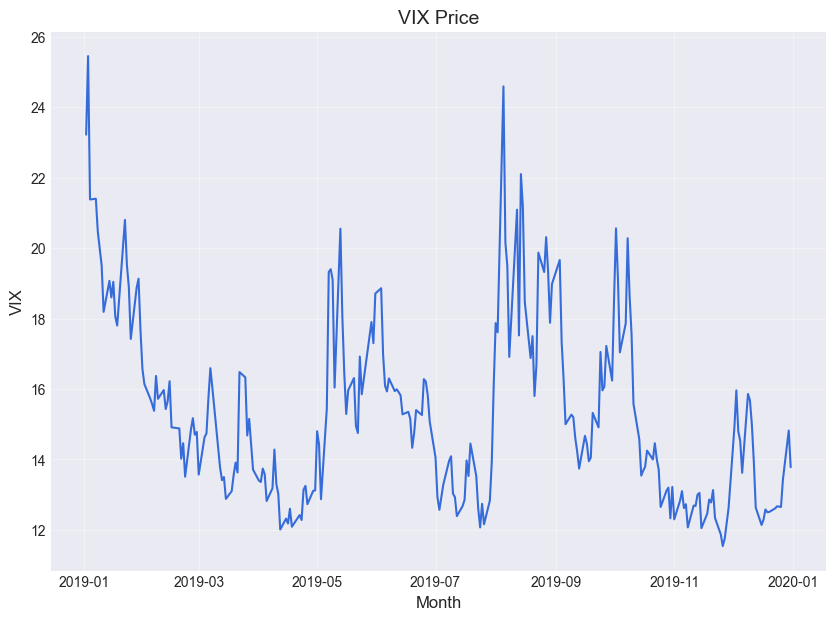

In [3]:
# Import libraries
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

# Plot the time series
plt.figure(figsize=(10, 7))
plt.plot(data['Close'])
# Plot the mean of the Price
data['mean'] = data['Close'].mean()
plt.plot(data['mean'])
plt.title('VIX Price', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('VIX', fontsize=12)
plt.show()

In [4]:
data = yf.download("WEAT", start="2011-01-01", end="2020-01-01")

[*********************100%***********************]  1 of 1 completed


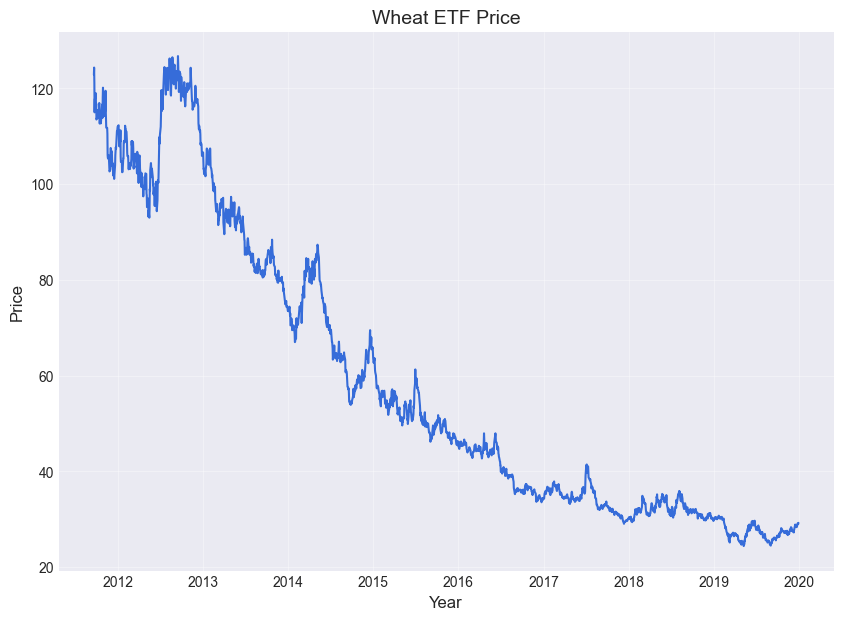

In [5]:
# Plot the time series
plt.figure(figsize=(10, 7))
plt.plot(data['Close'])
plt.title('Wheat ETF Price', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data.Close)
print('ADF Test Statistic: %.2f' % result[0])
print('5%% Critical Value: %.2f' % result[4]['5%'])
print('p-value: %.2f' % result[1])

ADF Test Statistic: -1.73
5% Critical Value: -2.86
p-value: 0.41


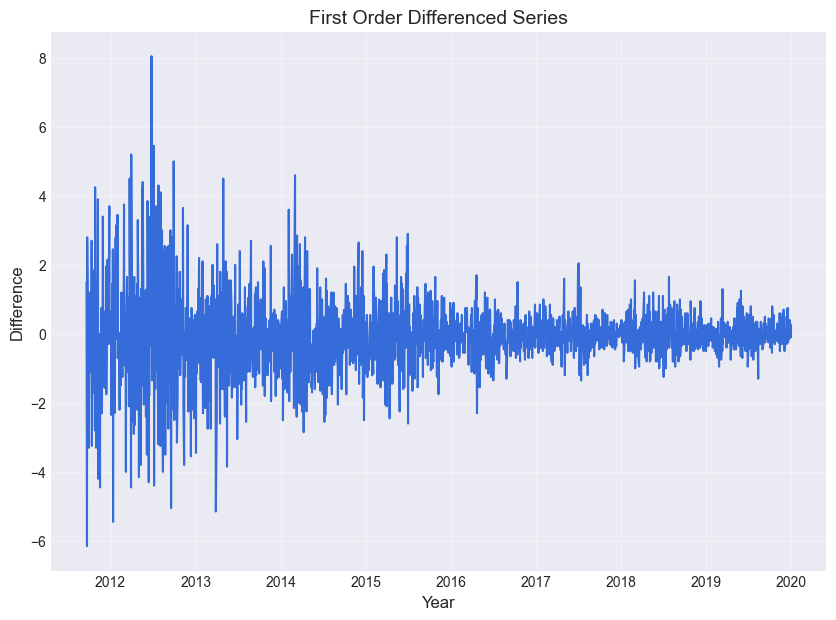

In [7]:
# Change for (t)th day is Close for (t)th day minus Close for (t-1)th day.
data['Difference'] = data['Close'].diff()

# Plot the Change
plt.figure(figsize=(10, 7))
plt.plot(data['Difference'])
plt.title('First Order Differenced Series', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Difference', fontsize=12)
plt.show()

In [8]:
result = adfuller(data.Difference.dropna())
print('ADF Test Statistic: %.2f' % result[0])
print('5%% Critical Value: %.2f' % result[4]['5%'])
print('p-value: %.2f' % result[1])

ADF Test Statistic: -8.88
5% Critical Value: -2.86
p-value: 0.00
